# Power Outage Forecasting — LSTM Models

This notebook builds two LSTM models to forecast power outages across 83 counties for 24h and 48h horizons.

We compare against four baseline models from `baseline_yuwenz.ipynb`:
- **Persistence**: predict tomorrow = today
- **Historical Median**: predict using the median outage at the same hour
- **Hurdle**: two-stage model (logistic + Poisson)
- **ZIP**: Zero-Inflated Poisson

Our two LSTM models:
- **LSTM-Simple**: uses top 10 weather features most correlated with outages
- **LSTM-Full**: uses all 77 valid weather features, letting the model learn on its own

The motivation is that LSTM can capture temporal dependencies in the outage time series, and adding weather features should help the model understand what external conditions drive outages.

## 1. Setup & Configuration

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

PROJECT_PATH = '/content/drive/MyDrive/MLPS'
os.chdir(PROJECT_PATH)
print(f"Working directory: {os.getcwd()}")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

DATA_DIR    = "data/"
RESULTS_DIR = "results/"
os.makedirs(RESULTS_DIR, exist_ok=True)

TRAIN_PATH    = os.path.join(DATA_DIR, "train.nc")
TEST_24H_PATH = os.path.join(DATA_DIR, "test_24h_demo.nc")
TEST_48H_PATH = os.path.join(DATA_DIR, "test_48h_demo.nc")

VALIDATION_SPLIT = 0.2
SEQ_LEN          = 24
BATCH_SIZE       = 64
EPOCHS           = 20
LR               = 1e-3
DEVICE           = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device: {DEVICE}")

Mounted at /content/drive
Working directory: /content/drive/MyDrive/MLPS
Device: cuda


## 2. Data Loading & Cleaning

We apply the same cleaning pipeline as in `baseline_yuwenz.ipynb` to keep things consistent:
1. **IQR outlier clipping** — weather values outside 1.5×IQR are replaced with NaN
2. **Linear interpolation** — fills the NaN gaps along the time dimension

The outage variable (`out`) is kept as-is. We then do a temporal 80/20 train/val split.

In [2]:
ds_train    = xr.open_dataset(TRAIN_PATH)
ds_test_24h = xr.open_dataset(TEST_24H_PATH)
ds_test_48h = xr.open_dataset(TEST_48H_PATH)

train_timestamps = pd.to_datetime(ds_train.timestamp.values)
locations        = [str(x) for x in ds_train.location.values]
weather_features = list(ds_train.feature.values)

print(f"Training Period  : {train_timestamps.min()} to {train_timestamps.max()}")
print(f"Number of Locations: {len(locations)}")
print(f"Weather Features ({len(weather_features)}): {weather_features}")

Training Period  : 2023-04-01 00:00:00 to 2023-06-30 00:00:00
Number of Locations: 83
Weather Features (109): ['SBT113', 'SBT114', 'SBT123', 'SBT124', 'aod', 'bgrun', 'blh', 'cape', 'cape_1', 'cfnsf', 'cfrzr', 'cicep', 'cin', 'cnwat', 'cpofp', 'crain', 'csnow', 'd2m', 'fricv', 'frzr', 'fsr', 'gflux', 'gh', 'gh_1', 'gh_2', 'gh_3', 'gh_4', 'gh_5', 'gh_6', 'gh_7', 'gust', 'hail', 'hail_1', 'hail_2', 'hcc', 'ishf', 'lai', 'layth', 'lcc', 'lftx', 'lftx4', 'lsm', 'ltng', 'max_10si', 'mcc', 'mdens', 'mslma', 'mstav', 'orog', 'pcdb', 'plpl', 'prate', 'pres', 'pres_1', 'pres_2', 'pt', 'pwat', 'r', 'r2', 'r_1', 'refc', 'refd', 'refd_1', 'sde', 'sdlwrf', 'sdswrf', 'sdwe', 'sdwe_1', 'sh2', 'siconc', 'slhtf', 'snowc', 'sp', 'ssrun', 'sulwrf', 'suswrf', 't', 't2m', 'tcc', 'tcc_1', 'tcoli', 'tcolw', 'tp', 'u', 'u10', 'unknown', 'unknown_1', 'unknown_2', 'unknown_3', 'unknown_4', 'unknown_5', 'unknown_6', 'unknown_7', 'unknown_8', 'unknown_9', 'ustm', 'v', 'v10', 'vbdsf', 'vddsf', 'veg', 'veril', 'vgt

In [3]:
'''# IQR outlier clipping
weather = ds_train.weather.copy()
Q1 = weather.quantile(0.25, dim="timestamp")
Q3 = weather.quantile(0.75, dim="timestamp")
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
weather_clean = weather.where((weather >= lower) & (weather <= upper))

# Linear interpolation
weather_filled = weather_clean.interpolate_na(dim="timestamp", method="linear")

# Rebuild clean dataset
ds_train_clean = xr.Dataset(
    {"weather": weather_filled, "tracked": ds_train.tracked, "out": ds_train.out},
    coords={"location": ds_train.location, "timestamp": ds_train.timestamp, "feature": ds_train.feature}
)
'''

weather = ds_train.weather.copy()
# Rebuild clean dataset
ds_train_clean = xr.Dataset(
    {"weather": weather, "tracked": ds_train.tracked, "out": ds_train.out},
    coords={"location": ds_train.location, "timestamp": ds_train.timestamp, "feature": ds_train.feature}
)

# Train/val split
all_timestamps = pd.to_datetime(ds_train_clean.timestamp.values)
T = ds_train_clean.dims["timestamp"]
split_idx = int((1 - VALIDATION_SPLIT) * T)

train_data = ds_train_clean.isel(timestamp=slice(0, split_idx))
val_data   = ds_train_clean.isel(timestamp=slice(split_idx, None))
train_ts   = all_timestamps[:split_idx]
val_ts     = all_timestamps[split_idx:]

print(f"Total timestamps : {T}")
print(f"Train            : {len(train_ts)} steps  ({train_ts[0]} → {train_ts[-1]})")
print(f"Val              : {len(val_ts)} steps  ({val_ts[0]} → {val_ts[-1]})")

Total timestamps : 2161
Train            : 1728 steps  (2023-04-01 00:00:00 → 2023-06-11 23:00:00)
Val              : 433 steps  (2023-06-12 00:00:00 → 2023-06-30 00:00:00)


## 3. Feature Engineering

The baseline models only use `lag_1`, `lag_24`, `hour`, and `dayofweek`. Here we do a more careful feature selection for the weather inputs.

**Step 1 — Remove all-zero features**: Some weather columns are entirely zero across the dataset. These carry no information and should be dropped.

**Step 2 — Correlation filter**: We compute the absolute correlation between each remaining weather feature and the outage count. Features with NaN correlation (constant or near-constant columns) are also removed.

**Step 3 — Define two feature sets**:
- `LSTM-Simple`: top 10 features by correlation — handpicked, interpretable
- `LSTM-Full`: all 77 valid features — let the model figure out what matters

In addition to weather, both models use:
- `lag_1`, `lag_24` — recent outage history
- `hour_sin/cos`, `dow_sin/cos` — cyclic time encodings (better than raw integers for capturing daily/weekly patterns)

In [4]:
# Step 1: Remove all-zero features
#weather_flat  = weather_filled.values.reshape(-1, weather_filled.shape[-1])
weather_flat  = weather.values.reshape(-1, weather.shape[-1])
all_zero_mask = np.all(weather_flat == 0, axis=0)
zero_features     = [weather_features[i] for i in range(len(weather_features)) if all_zero_mask[i]]
non_zero_features = [f for f in weather_features if f not in zero_features]

print(f"Excluded all-zero features ({len(zero_features)}): {zero_features}")
print(f"Remaining non-zero features: {len(non_zero_features)}")

# Step 2: Compute correlation with outage target
out_flat   = ds_train.out.values.flatten()
df_weather = pd.DataFrame(weather_flat, columns=weather_features)
df_weather['out'] = out_flat

target_corr = df_weather[non_zero_features + ['out']].corr()['out'].drop('out')

# Remove NaN correlation features
nan_corr_features = target_corr[target_corr.isna()].index.tolist()
valid_features    = [f for f in non_zero_features if f not in nan_corr_features]

print(f"Excluded NaN correlation features ({len(nan_corr_features)}): {nan_corr_features}")
print(f"Final valid weather features: {len(valid_features)}")

# Step 3: Rank and define feature sets
target_corr_valid = target_corr[valid_features].abs().sort_values(ascending=False)
print(f"\nTop 10 weather features by correlation with outage:")
print(target_corr_valid.head(10))

selected_weather_features = target_corr_valid.head(10).index.tolist()  # LSTM-Simple
all_weather_features      = valid_features                              # LSTM-Full

print(f"\nLSTM-Simple weather features ({len(selected_weather_features)}): {selected_weather_features}")
print(f"LSTM-Full   weather features ({len(all_weather_features)}): {len(all_weather_features)} features")

Excluded all-zero features (17): ['aod', 'bgrun', 'cfrzr', 'cicep', 'crain', 'csnow', 'hail_2', 'ltng', 'prate', 'sdwe_1', 'siconc', 'ssrun', 'tcoli', 'tcolw', 'tp', 'unknown_7', 'unknown_9']
Remaining non-zero features: 92
Excluded NaN correlation features (0): []
Final valid weather features: 92

Top 10 weather features by correlation with outage:
cape         0.119191
pwat         0.089700
sh2          0.083554
gh_4         0.081504
cape_1       0.073289
sdlwrf       0.068874
unknown_3    0.061608
refc         0.059532
lcc          0.055376
hail         0.054625
Name: out, dtype: float64

LSTM-Simple weather features (10): ['cape', 'pwat', 'sh2', 'gh_4', 'cape_1', 'sdlwrf', 'unknown_3', 'refc', 'lcc', 'hail']
LSTM-Full   weather features (92): 92 features


## 4. Build Feature Matrices

We convert the xarray dataset into a 3D numpy array of shape `(T, L, D)` where:
- `T` = number of timestamps
- `L` = number of locations (83 counties)
- `D` = number of features per location-time pair

Features included for each location at each timestep:
- `out` (current outage count)
- `lag_1`, `lag_24` (outage 1h and 24h ago)
- `hour_sin`, `hour_cos`, `dow_sin`, `dow_cos` (cyclic time encodings)
- selected or all weather features

In [5]:
def build_feature_matrix(ds, ts, weather_feats):
    out_vals = ds.out.transpose("timestamp", "location").values.astype(float)
    T, L = out_vals.shape

    def lag(arr, k):
        shifted = np.full_like(arr, np.nan)
        shifted[k:] = arr[:-k]
        return shifted

    lag1  = lag(out_vals, 1)
    lag24 = lag(out_vals, 24)

    hour_sin = np.sin(2 * np.pi * ts.hour / 24).values[:, None] * np.ones((1, L))
    hour_cos = np.cos(2 * np.pi * ts.hour / 24).values[:, None] * np.ones((1, L))
    dow_sin  = np.sin(2 * np.pi * ts.dayofweek / 7).values[:, None] * np.ones((1, L))
    dow_cos  = np.cos(2 * np.pi * ts.dayofweek / 7).values[:, None] * np.ones((1, L))

    w_vals = ds.weather.sel(feature=weather_feats).transpose(
        "timestamp", "location", "feature"
    ).values.astype(float)

    base = np.stack([out_vals, lag1, lag24, hour_sin, hour_cos, dow_sin, dow_cos], axis=-1)
    X = np.concatenate([base, w_vals], axis=-1)
    return X, out_vals

print("Building feature matrix for LSTM-Simple...")
X_simple, y = build_feature_matrix(ds_train_clean, all_timestamps, selected_weather_features)
print(f"  Shape: {X_simple.shape}  → (T, L, {X_simple.shape[-1]} features)")

print("Building feature matrix for LSTM-Full...")
X_full, _   = build_feature_matrix(ds_train_clean, all_timestamps, all_weather_features)
print(f"  Shape: {X_full.shape}  → (T, L, {X_full.shape[-1]} features)")

Building feature matrix for LSTM-Simple...
  Shape: (2161, 83, 17)  → (T, L, 17 features)
Building feature matrix for LSTM-Full...
  Shape: (2161, 83, 99)  → (T, L, 99 features)


## 5. Train/Val Split & Normalization

We normalize features using z-score normalization. Importantly, the scaler is fitted on the **training set only** and then applied to both train and val — this avoids data leakage.

In [6]:
X_simple_tr, X_simple_va = X_simple[:split_idx], X_simple[split_idx:]
X_full_tr,   X_full_va   = X_full[:split_idx],   X_full[split_idx:]
y_tr,        y_va        = y[:split_idx],         y[split_idx:]

# LSTM-Base: outage only
X_base_tr = y_tr[:, :, np.newaxis]   # (T, L, 1)
X_base_va = y_va[:, :, np.newaxis]

print(f"Train: {X_simple_tr.shape[0]} steps")
print(f"Val  : {X_simple_va.shape[0]} steps")

def fit_scaler(arr):
    flat = arr.reshape(-1, arr.shape[-1])
    mu = np.nanmean(flat, axis=0)
    sd = np.nanstd(flat,  axis=0)
    sd = np.where(sd == 0, 1.0, sd)
    return mu, sd

def apply_scaler(arr, mu, sd):
    return (arr - mu) / sd

mu_simple, sd_simple = fit_scaler(X_simple_tr)
mu_full,   sd_full   = fit_scaler(X_full_tr)
mu_base,   sd_base   = fit_scaler(X_base_tr)

X_simple_tr_n = apply_scaler(np.nan_to_num(X_simple_tr, 0), mu_simple, sd_simple)
X_simple_va_n = apply_scaler(np.nan_to_num(X_simple_va, 0), mu_simple, sd_simple)
X_full_tr_n   = apply_scaler(np.nan_to_num(X_full_tr, 0), mu_full, sd_full)
X_full_va_n   = apply_scaler(np.nan_to_num(X_full_va, 0), mu_full, sd_full)
X_base_tr_n   = apply_scaler(np.nan_to_num(X_base_tr, 0), mu_base, sd_base)
X_base_va_n   = apply_scaler(np.nan_to_num(X_base_va, 0), mu_base, sd_base)

print("✓ Normalization done")

Train: 1728 steps
Val  : 433 steps
✓ Normalization done


In [7]:
# LSTM-Base: outage sequence only, no weather, no time features
def build_base_feature_matrix(ds):
    out_vals = ds.out.transpose("timestamp", "location").values.astype(float)  # (T, L, 1)
    X = out_vals[:, :, np.newaxis]  # (T, L, 1)
    return X, out_vals

print("Building feature matrix for LSTM-Base...")
X_base, _ = build_base_feature_matrix(ds_train_clean)
print(f"  Shape: {X_base.shape}  → (T, L, 1 feature)")

X_base_tr, X_base_va = X_base[:split_idx], X_base[split_idx:]

mu_base, sd_base = fit_scaler(X_base_tr)
X_base_tr_n = apply_scaler(np.nan_to_num(X_base_tr, 0), mu_base, sd_base)
X_base_va_n = apply_scaler(np.nan_to_num(X_base_va, 0), mu_base, sd_base)

print("✓ LSTM-Base normalization done")

Building feature matrix for LSTM-Base...
  Shape: (2161, 83, 1)  → (T, L, 1 feature)
✓ LSTM-Base normalization done


## 6. Sliding Window Dataset

LSTM models require sequential input. We use a sliding window approach:
- **Input**: the past `SEQ_LEN=24` hours of features for one location
- **Target**: the next `horizon` hours of outage counts

We slide this window across all timestamps and all 83 locations, giving us a large training dataset.

In [8]:
def build_windows(X_norm, y_raw, seq_len, horizon):
    T, L, D = X_norm.shape
    inputs, targets = [], []
    for loc_idx in range(L):
        x_loc = X_norm[:, loc_idx, :]
        y_loc = y_raw[:, loc_idx]
        for t in range(T - seq_len - horizon + 1):
            inp = x_loc[t : t + seq_len]
            tgt = y_loc[t + seq_len : t + seq_len + horizon]
            if np.isnan(inp).any() or np.isnan(tgt).any():
                continue
            inputs.append(inp)
            targets.append(tgt)
    return np.array(inputs, dtype=np.float32), np.array(targets, dtype=np.float32)

print("Building windows for LSTM-Base...")
X_win_base_24, y_win_24 = build_windows(X_base_tr_n, y_tr, SEQ_LEN, 24)
X_win_base_48, y_win_48 = build_windows(X_base_tr_n, y_tr, SEQ_LEN, 48)
print(f"  24h: inputs {X_win_base_24.shape} targets {y_win_24.shape}")
print(f"  48h: inputs {X_win_base_48.shape} targets {y_win_48.shape}")

print("Building windows for LSTM-Simple...")
X_win_simple_24, y_win_24 = build_windows(X_simple_tr_n, y_tr, SEQ_LEN, 24)
X_win_simple_48, y_win_48 = build_windows(X_simple_tr_n, y_tr, SEQ_LEN, 48)
print(f"  24h: inputs {X_win_simple_24.shape}  targets {y_win_24.shape}")
print(f"  48h: inputs {X_win_simple_48.shape}  targets {y_win_48.shape}")

print("Building windows for LSTM-Full...")
X_win_full_24, _ = build_windows(X_full_tr_n, y_tr, SEQ_LEN, 24)
X_win_full_48, _ = build_windows(X_full_tr_n, y_tr, SEQ_LEN, 48)
print(f"  24h: inputs {X_win_full_24.shape}  targets {y_win_24.shape}")
print(f"  48h: inputs {X_win_full_48.shape}  targets {y_win_48.shape}")



Building windows for LSTM-Base...
  24h: inputs (139523, 24, 1) targets (139523, 24)
  48h: inputs (137531, 24, 1) targets (137531, 48)
Building windows for LSTM-Simple...
  24h: inputs (139523, 24, 17)  targets (139523, 24)
  48h: inputs (137531, 24, 17)  targets (137531, 48)
Building windows for LSTM-Full...
  24h: inputs (139523, 24, 99)  targets (139523, 24)
  48h: inputs (137531, 24, 99)  targets (137531, 48)


## 7. Model Architecture

We use a standard LSTM with a two-layer MLP output head. The same architecture is used for both LSTM-Simple and LSTM-Full — the only difference is the input dimension.

Key design choices:
- **2-layer LSTM** with hidden size 64 — enough capacity without being too heavy
- **Dropout 0.2** between layers — regularization to prevent overfitting
- **ReLU + clamp(min=0)** on output — outage counts are always non-negative
- **Gradient clipping** during training — stabilizes LSTM training

In [9]:
class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, num_layers=3, dropout=0.3, horizon=24):
        super().__init__()
        self.lstm = nn.LSTM(
            input_dim, hidden_dim, num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, horizon)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        last   = out[:, -1, :]
        pred   = self.head(last)
        return torch.clamp(pred, min=0.0)

# Sanity check
dummy_base = torch.zeros(4, SEQ_LEN, X_win_base_24.shape[-1])
dummy_simple = torch.zeros(4, SEQ_LEN, X_win_simple_24.shape[-1])
dummy_full   = torch.zeros(4, SEQ_LEN, X_win_full_24.shape[-1])

m = LSTMModel(input_dim=X_win_base_24.shape[-1], horizon=24)
print(f"LSTM-Base output shape: {m(dummy_base).shape}  ✓")
m = LSTMModel(input_dim=X_win_simple_24.shape[-1], horizon=24)
print(f"LSTM-Simple output shape: {m(dummy_simple).shape}  ✓")
m = LSTMModel(input_dim=X_win_full_24.shape[-1], horizon=24)
print(f"LSTM-Full   output shape: {m(dummy_full).shape}  ✓")

n_params_base = sum(p.numel() for p in LSTMModel(X_win_base_24.shape[-1]).parameters())
n_params_simple = sum(p.numel() for p in LSTMModel(X_win_simple_24.shape[-1]).parameters())
n_params_full   = sum(p.numel() for p in LSTMModel(X_win_full_24.shape[-1]).parameters())
print(f"\nLSTM-Base parameters: {n_params_base:,}")
print(f"LSTM-Simple parameters: {n_params_simple:,}")
print(f"LSTM-Full   parameters: {n_params_full:,}")

LSTM-Base output shape: torch.Size([4, 24])  ✓
LSTM-Simple output shape: torch.Size([4, 24])  ✓
LSTM-Full   output shape: torch.Size([4, 24])  ✓

LSTM-Base parameters: 357,848
LSTM-Simple parameters: 366,040
LSTM-Full   parameters: 408,024


## 8. Training Function

In [10]:
def train_model(X_windows, y_windows, input_dim, horizon, epochs=EPOCHS,
                batch_size=BATCH_SIZE, lr=LR, model_name="LSTM"):
    dataset   = TensorDataset(torch.tensor(X_windows), torch.tensor(y_windows))
    loader    = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    model     = LSTMModel(input_dim=input_dim, horizon=horizon).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)
    criterion = nn.MSELoss()
    history   = []
    for epoch in tqdm(range(epochs), desc=f"Training {model_name} {horizon}h"):
        model.train()
        epoch_loss = 0.0
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            epoch_loss += loss.item() * len(xb)
        epoch_loss /= len(dataset)
        history.append(epoch_loss)
        scheduler.step()
    return model, history

## 9. Train LSTM-Base

LSTM-Base only use the outrage sequence with no feature included in the model

Training LSTM-Base 24h...


Training LSTM-Base 24h:   0%|          | 0/20 [00:00<?, ?it/s]


Training LSTM-Base 48h...


Training LSTM-Base 48h:   0%|          | 0/20 [00:00<?, ?it/s]


✓ LSTM-Base training done!


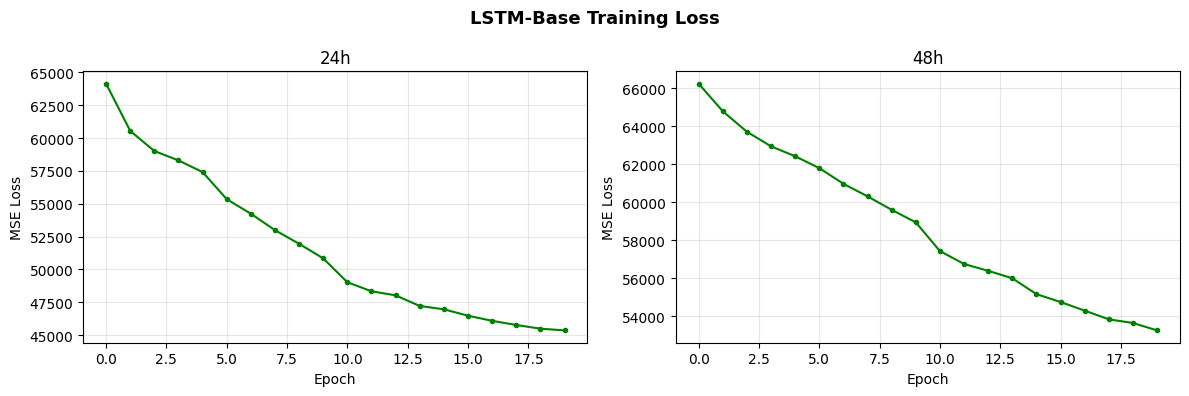

In [11]:
print("Training LSTM-Base 24h...")
model_base_24h, hist_base_24h = train_model(
    X_win_base_24, y_win_24, X_win_base_24.shape[-1], 24, model_name="LSTM-Base")

print("\nTraining LSTM-Base 48h...")
model_base_48h, hist_base_48h = train_model(
    X_win_base_48, y_win_48, X_win_base_48.shape[-1], 48, model_name="LSTM-Base")

print("\n✓ LSTM-Base training done!")

#Plot loss curve
fig, axes = plt.subplots(1, 2, figsize=(12,4))
fig.suptitle("LSTM-Base Training Loss", fontsize=13, fontweight='bold')
for ax, hist, title in zip(axes, [hist_base_24h, hist_base_48h], ['24h', '48h']):
    ax.plot(hist, marker='o', markersize=3, color='green')
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MSE Loss")
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "loss_base.png"), dpi=120)
plt.show()

## 10. Train LSTM-Simple

LSTM-Simple uses the top 10 weather features selected by correlation analysis. We train separate models for 24h and 48h prediction horizons.

Training LSTM-Simple 24h...


Training LSTM-Simple 24h:   0%|          | 0/20 [00:00<?, ?it/s]


Training LSTM-Simple 48h...


Training LSTM-Simple 48h:   0%|          | 0/20 [00:00<?, ?it/s]


✓ LSTM-Simple training done!


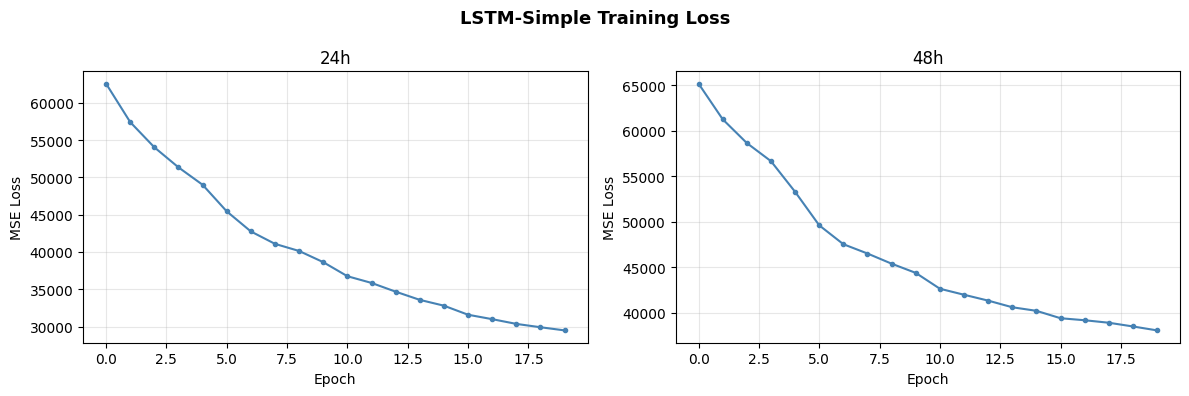

In [12]:
print("Training LSTM-Simple 24h...")
model_simple_24h, hist_simple_24h = train_model(
    X_win_simple_24, y_win_24, X_win_simple_24.shape[-1], 24, model_name="LSTM-Simple")

print("\nTraining LSTM-Simple 48h...")
model_simple_48h, hist_simple_48h = train_model(
    X_win_simple_48, y_win_48, X_win_simple_48.shape[-1], 48, model_name="LSTM-Simple")

print("\n✓ LSTM-Simple training done!")

# Plot loss curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("LSTM-Simple Training Loss", fontsize=13, fontweight='bold')
for ax, hist, title in zip(axes, [hist_simple_24h, hist_simple_48h], ['24h', '48h']):
    ax.plot(hist, marker='o', markersize=3, color='steelblue')
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MSE Loss")
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "loss_simple.png"), dpi=120)
plt.show()

## 10. Train LSTM-Full

LSTM-Full uses all 77 valid weather features. The idea is to give the model more information and let it learn which features are useful through the training process.

Training LSTM-Full 24h...


Training LSTM-Full 24h:   0%|          | 0/20 [00:00<?, ?it/s]


Training LSTM-Full 48h...


Training LSTM-Full 48h:   0%|          | 0/20 [00:00<?, ?it/s]


✓ LSTM-Full training done!


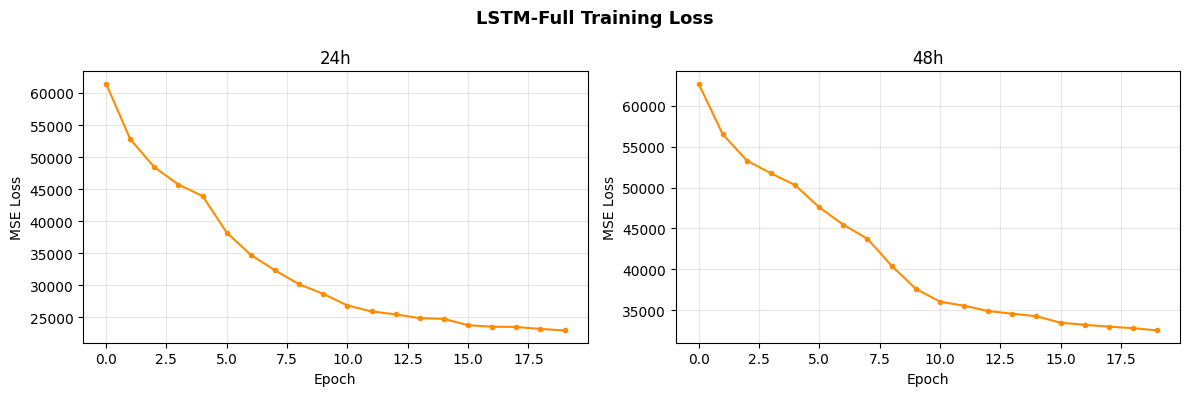

In [13]:
print("Training LSTM-Full 24h...")
model_full_24h, hist_full_24h = train_model(
    X_win_full_24, y_win_24, X_win_full_24.shape[-1], 24, model_name="LSTM-Full")

print("\nTraining LSTM-Full 48h...")
model_full_48h, hist_full_48h = train_model(
    X_win_full_48, y_win_48, X_win_full_48.shape[-1], 48, model_name="LSTM-Full")

print("\n✓ LSTM-Full training done!")

# Plot loss curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("LSTM-Full Training Loss", fontsize=13, fontweight='bold')
for ax, hist, title in zip(axes, [hist_full_24h, hist_full_48h], ['24h', '48h']):
    ax.plot(hist, marker='o', markersize=3, color='darkorange')
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MSE Loss")
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "loss_full.png"), dpi=120)
plt.show()

## 11. Validation Predictions

In [14]:
def predict_with_timestamps(model, X_context_norm, horizon, locations, timestamps):
    model.eval()
    context = X_context_norm[-SEQ_LEN:, :, :]
    inp     = torch.tensor(context.transpose(1, 0, 2), dtype=torch.float32).to(DEVICE)
    with torch.no_grad():
        preds = model(inp).cpu().numpy()
    rows = []
    for loc_idx, loc in enumerate(locations):
        for h in range(horizon):
            rows.append({"step": h, "location": loc, "pred": float(preds[loc_idx, h])})
    df = pd.DataFrame(rows)
    df['timestamp'] = df['step'].apply(lambda i: timestamps[i] if i < len(timestamps) else None)
    return df[['timestamp', 'location', 'pred']].dropna(subset=['timestamp']).reset_index(drop=True)

print("Generating validation predictions...")
val_base_24h = predict_with_timestamps(model_base_24h, X_base_tr_n, 24, locations, val_ts)
val_base_48h = predict_with_timestamps(model_base_48h, X_base_tr_n, 48, locations, val_ts)
val_simple_24h = predict_with_timestamps(model_simple_24h, X_simple_tr_n, 24, locations, val_ts)
val_simple_48h = predict_with_timestamps(model_simple_48h, X_simple_tr_n, 48, locations, val_ts)
val_full_24h   = predict_with_timestamps(model_full_24h,   X_full_tr_n,   24, locations, val_ts)
val_full_48h   = predict_with_timestamps(model_full_48h,   X_full_tr_n,   48, locations, val_ts)


print(f"Val 24h predictions: {len(val_simple_24h)} rows  (expected {24 * len(locations)})")
print(f"Val 48h predictions: {len(val_simple_48h)} rows  (expected {48 * len(locations)})")

print(f"Val timestamps: {len(val_ts)} steps")
print(f"First: {val_ts[0]}")
print(f"Last : {val_ts[-1]}")
print(val_ts[:5])

Generating validation predictions...
Val 24h predictions: 1992 rows  (expected 1992)
Val 48h predictions: 3984 rows  (expected 3984)
Val timestamps: 433 steps
First: 2023-06-12 00:00:00
Last : 2023-06-30 00:00:00
DatetimeIndex(['2023-06-12 00:00:00', '2023-06-12 01:00:00',
               '2023-06-12 02:00:00', '2023-06-12 03:00:00',
               '2023-06-12 04:00:00'],
              dtype='datetime64[ns]', freq=None)


## 12. Model Comparison

We compare all models on the same validation set using average RMSE across all 83 counties.

Baseline results from `baseline_yuwenz.ipynb`:
- Persistence: 93.69
- Historical Median: 277.77
- Hurdle: 106563.83 (diverged)
- ZIP: 280.65

In [15]:
def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((np.array(y_true) - np.array(y_pred)) ** 2)))

def evaluate_avg_rmse(pred_df, truth_arr, locations):
    H = truth_arr.shape[0]
    rmses = []
    for i, loc in enumerate(locations):
        pv = pred_df[pred_df['location'].astype(str) == str(loc)]['pred'].values
        if len(pv) >= H:
            rmses.append(rmse(truth_arr[:, i], pv[:H]))
    return np.nanmean(rmses)

# Ground truth
val_truth_24h = ds_train_clean.out.transpose("timestamp", "location").isel(
    timestamp=slice(split_idx, split_idx + 24)).values.astype(float)
val_truth_48h = ds_train_clean.out.transpose("timestamp", "location").isel(
    timestamp=slice(split_idx, split_idx + 48)).values.astype(float)

# LSTM results
rmse_base_24h = evaluate_avg_rmse(val_base_24h, val_truth_24h, locations)
rmse_base_48h = evaluate_avg_rmse(val_base_48h, val_truth_48h, locations)
rmse_simple_24h = evaluate_avg_rmse(val_simple_24h, val_truth_24h, locations)
rmse_simple_48h = evaluate_avg_rmse(val_simple_48h, val_truth_48h, locations)
rmse_full_24h   = evaluate_avg_rmse(val_full_24h,   val_truth_24h, locations)
rmse_full_48h   = evaluate_avg_rmse(val_full_48h,   val_truth_48h, locations)

# Zero baseline
rmse_zero_24h = float(np.sqrt(np.mean(val_truth_24h ** 2)))
rmse_zero_48h = float(np.sqrt(np.mean(val_truth_48h ** 2)))

# Full comparison table including baselines from baseline_yuwenz.ipynb
results = pd.DataFrame({
    'Model': [
        'Zero Baseline',
        'Persistence',
        'Historical Median',
        'Hurdle',
        'ZIP',
        'LSTM-BASE （with only historical outrage）',
        'LSTM-Simple (top 10 weather)',
        'LSTM-Full (all 77 weather)'
    ],
    'RMSE 24h': [
        round(rmse_zero_24h, 4),
        93.6870,
        277.7680,
        106563.8301,
        280.6458,
        round(rmse_base_24h, 4),
        round(rmse_simple_24h, 4),
        round(rmse_full_24h, 4)
    ],
    'RMSE 48h': [
        round(rmse_zero_48h, 4),
        'N/A',
        'N/A',
        'N/A',
        'N/A',
        round(rmse_base_48h, 4),
        round(rmse_simple_48h, 4),
        round(rmse_full_48h, 4)
    ]
})

print("=" * 65)
print("Model Comparison — Validation RMSE")
print("=" * 65)
print(results.to_string(index=False))

Model Comparison — Validation RMSE
                                   Model    RMSE 24h  RMSE 48h
                           Zero Baseline    292.5593  209.9249
                             Persistence     93.6870       N/A
                       Historical Median    277.7680       N/A
                                  Hurdle 106563.8301       N/A
                                     ZIP    280.6458       N/A
LSTM-BASE （with only historical outrage）     90.5149   65.6764
            LSTM-Simple (top 10 weather)     98.5258   64.4018
              LSTM-Full (all 77 weather)     97.9595   81.0926


## 13. Visualization — Predictions vs Ground Truth

We plot predictions for the top 5 counties by mean outage count to visually compare LSTM-Simple and LSTM-Full against the ground truth.

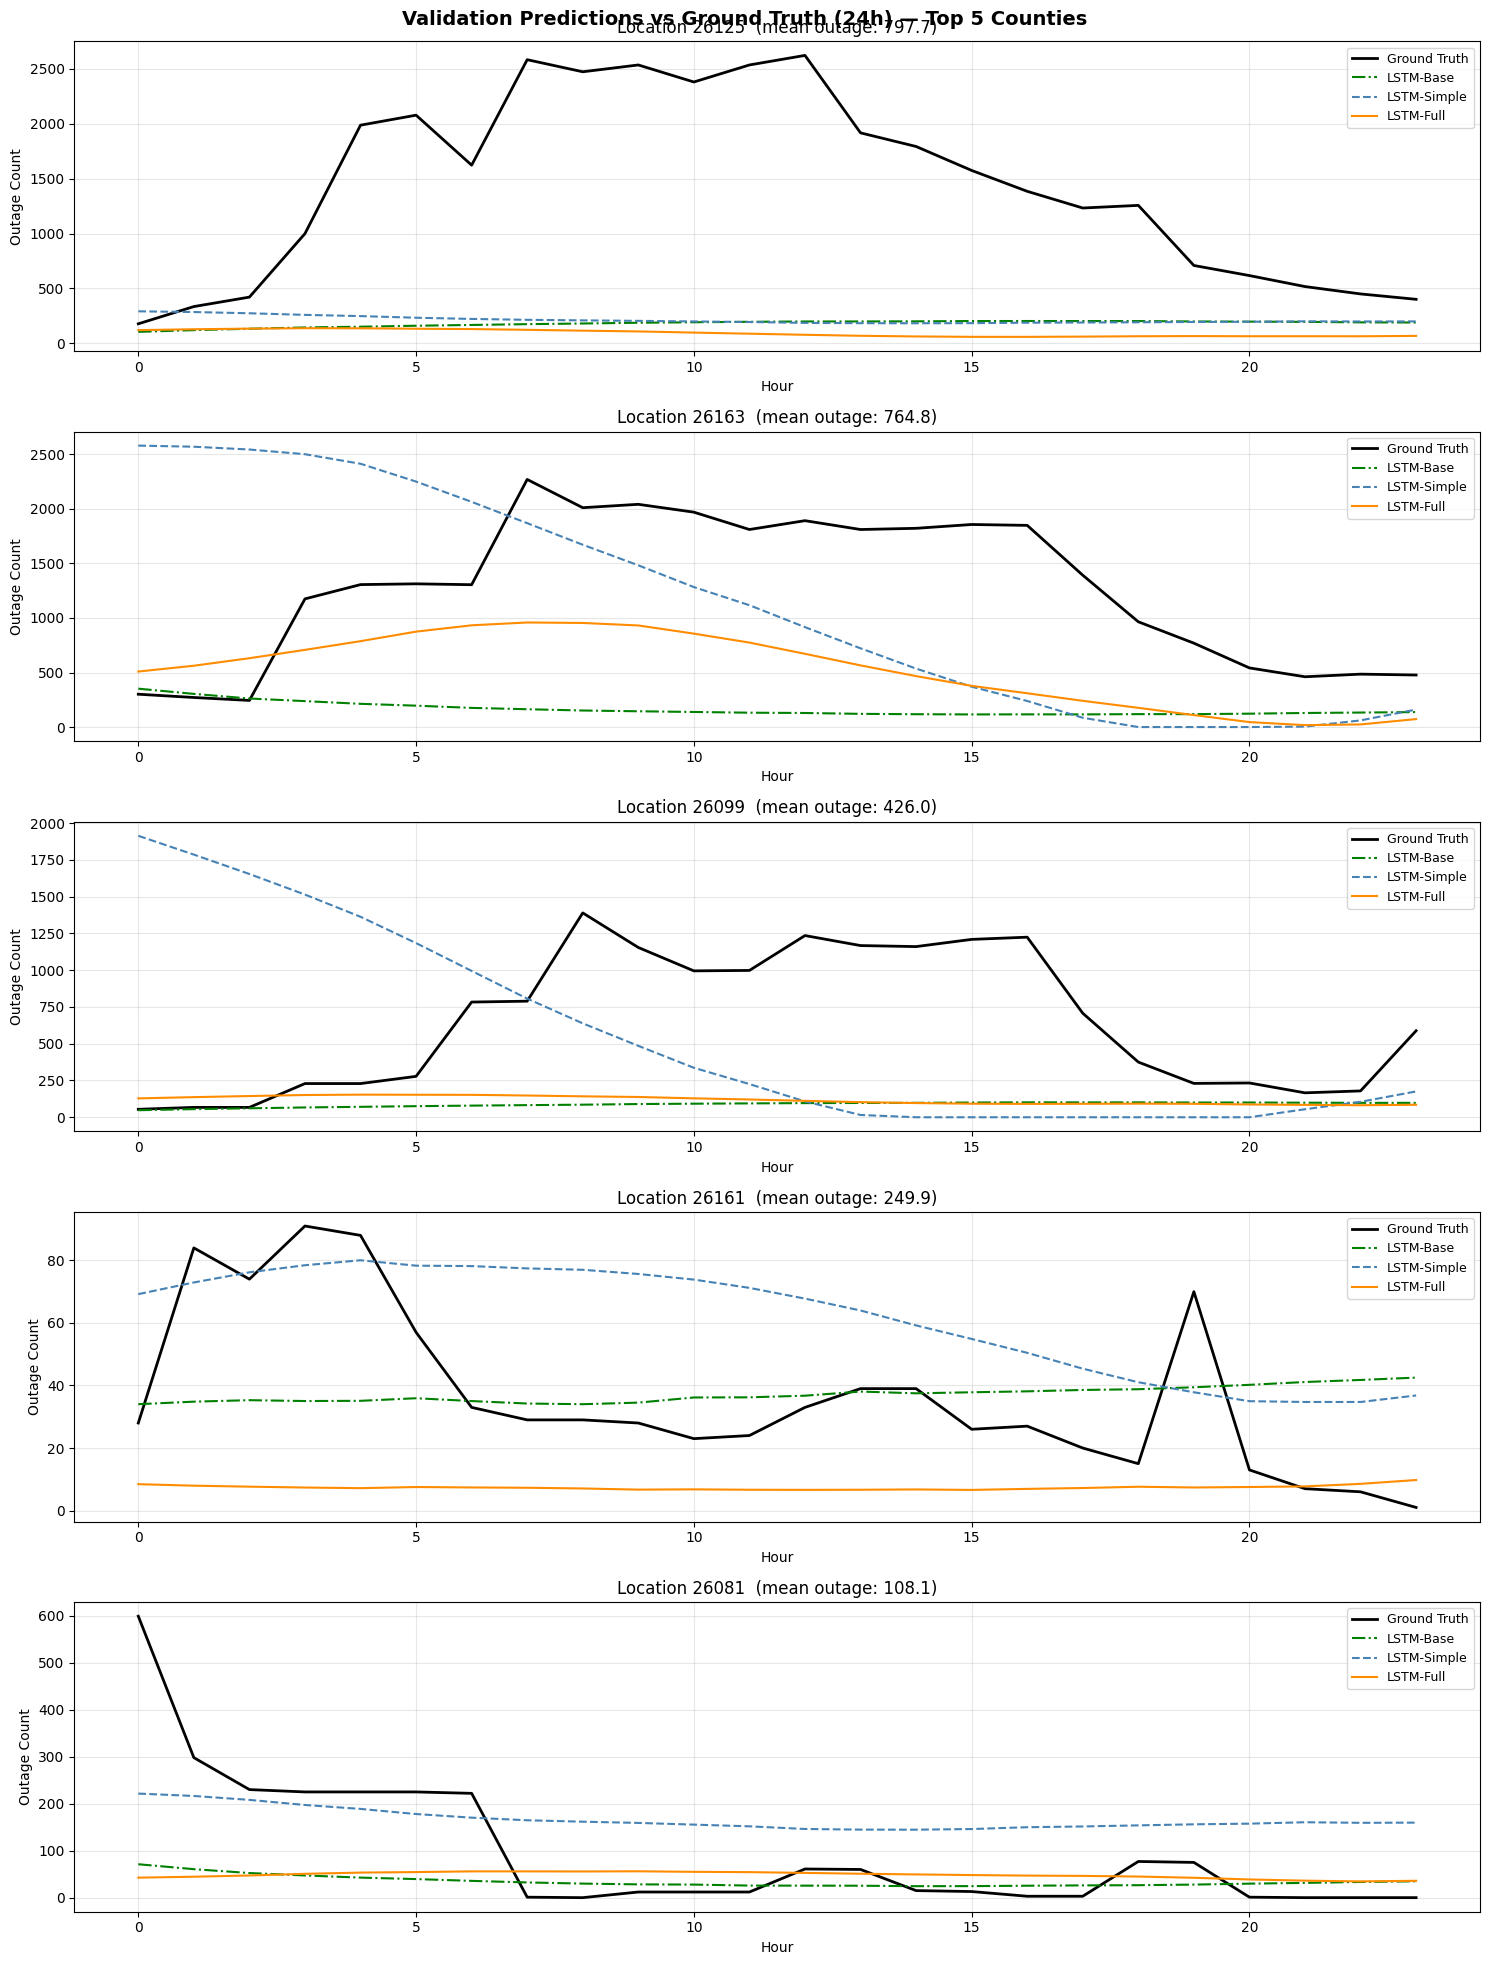

In [16]:
# Top 5 counties by mean outage
mean_out  = ds_train_clean.out.mean(dim="timestamp").values
top5_idx  = np.argsort(mean_out)[::-1][:5]
top5_locs = [locations[i] for i in top5_idx]

fig, axes = plt.subplots(5, 1, figsize=(15, 20))
fig.suptitle("Validation Predictions vs Ground Truth (24h) — Top 5 Counties",
             fontsize=14, fontweight='bold')

for ax, loc in zip(axes, top5_locs):
    loc_idx     = locations.index(loc)
    truth       = val_truth_24h[:, loc_idx]
    base_pred   = val_base_24h[val_base_24h['location'].astype(str) == str(loc)]['pred'].values[:24]
    simple_pred = val_simple_24h[val_simple_24h['location'].astype(str) == str(loc)]['pred'].values[:24]
    full_pred   = val_full_24h[val_full_24h['location'].astype(str) == str(loc)]['pred'].values[:24]

    ax.plot(truth, label='Ground Truth', color='black', linewidth=2)
    if len(base_pred) == 24:
        ax.plot(base_pred, label='LSTM-Base', color='green', linewidth=1.5, linestyle='-.')
    if len(simple_pred) == 24:
        ax.plot(simple_pred, label='LSTM-Simple', color='steelblue', linewidth=1.5, linestyle='--')
    if len(full_pred) == 24:
        ax.plot(full_pred, label='LSTM-Full', color='darkorange', linewidth=1.5)

    ax.set_title(f"Location {loc}  (mean outage: {mean_out[loc_idx]:.1f})")
    ax.set_xlabel("Hour")
    ax.set_ylabel("Outage Count")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "validation_predictions_24h.png"), dpi=120)
plt.show()

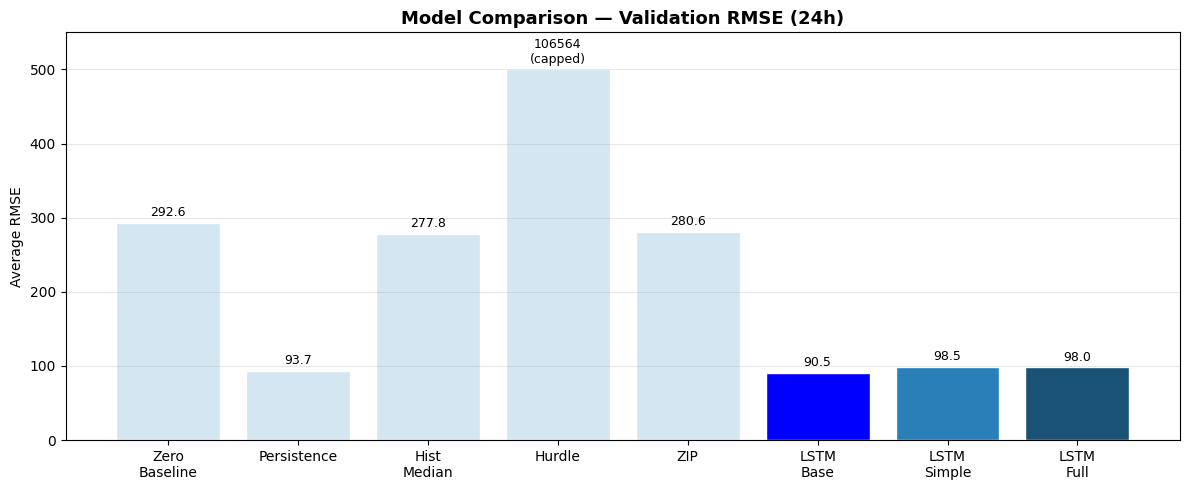

In [17]:
plot_models = [
    'Zero\nBaseline',
    'Persistence',
    'Hist\nMedian',
    'Hurdle',
    'ZIP',
    'LSTM\nBase',
    'LSTM\nSimple',
    'LSTM\nFull'
]

plot_vals_24 = [
    rmse_zero_24h,
    93.6870,
    277.7680,
    106563.8301,
    280.6458,
    rmse_base_24h,
    rmse_simple_24h,
    rmse_full_24h
]

# Cap Hurdle for visualization
plot_vals_24_capped = [min(v, 500) for v in plot_vals_24]
colors = ['#d4e6f1'] * 5 + ['#0000ff', '#2980b9', '#1a5276']

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(plot_models, plot_vals_24_capped, color=colors, edgecolor='white')

for bar, val in zip(bars, plot_vals_24):
    label = f'{val:.1f}' if val < 500 else f'{val:.0f}\n(capped)'
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        label,
        ha='center',
        va='bottom',
        fontsize=9
    )

ax.set_title("Model Comparison — Validation RMSE (24h)", fontsize=13, fontweight='bold')
ax.set_ylabel("Average RMSE")
ax.set_ylim(0, 550)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "model_comparison_bar.png"), dpi=120)
plt.show()

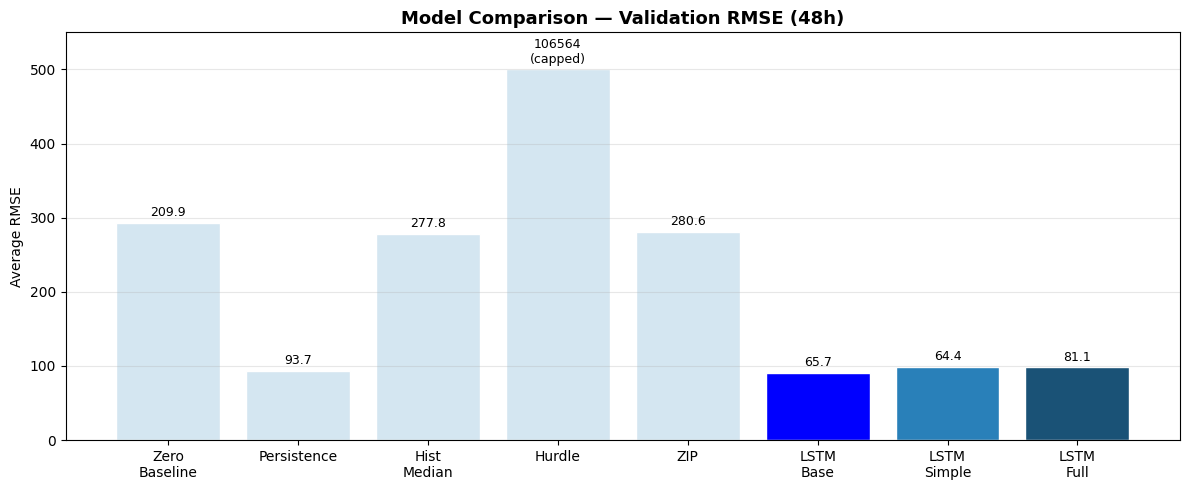

In [18]:
plot_models = [
    'Zero\nBaseline',
    'Persistence',
    'Hist\nMedian',
    'Hurdle',
    'ZIP',
    'LSTM\nBase',
    'LSTM\nSimple',
    'LSTM\nFull'
]

plot_vals_48 = [
    rmse_zero_48h,
    93.6870,
    277.7680,
    106563.8301,
    280.6458,
    rmse_base_48h,
    rmse_simple_48h,
    rmse_full_48h
]

# Cap Hurdle for visualization
plot_vals_48_capped = [min(v, 500) for v in plot_vals_48]
colors = ['#d4e6f1'] * 5 + ['#0000ff', '#2980b9', '#1a5276']

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(plot_models, plot_vals_24_capped, color=colors, edgecolor='white')

for bar, val in zip(bars, plot_vals_48):
    label = f'{val:.1f}' if val < 500 else f'{val:.0f}\n(capped)'
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        label,
        ha='center',
        va='bottom',
        fontsize=9
    )

ax.set_title("Model Comparison — Validation RMSE (48h)", fontsize=13, fontweight='bold')
ax.set_ylabel("Average RMSE")
ax.set_ylim(0, 550)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "model_comparison_bar.png"), dpi=120)
plt.show()

## 14. Generate Test Set Predictions

We retrain both LSTM models on the **full training data** (train + val) before generating test predictions. This gives the model as much data as possible before the final evaluation.

In [19]:
# Retrain on full data
mu_simple_full, sd_simple_full = fit_scaler(X_simple)
mu_full_full,   sd_full_full   = fit_scaler(X_full)

X_simple_n = apply_scaler(np.nan_to_num(X_simple, 0), mu_simple_full, sd_simple_full)
X_full_n   = apply_scaler(np.nan_to_num(X_full, 0),   mu_full_full,   sd_full_full)

X_win_simple_24_final, y_win_24_final = build_windows(X_simple_n, y, SEQ_LEN, 24)
X_win_simple_48_final, y_win_48_final = build_windows(X_simple_n, y, SEQ_LEN, 48)
X_win_full_24_final, _                = build_windows(X_full_n,   y, SEQ_LEN, 24)
X_win_full_48_final, _                = build_windows(X_full_n,   y, SEQ_LEN, 48)

print("Retraining on full data...")
final_simple_24h, _ = train_model(X_win_simple_24_final, y_win_24_final, X_win_simple_24_final.shape[-1], 24, model_name="Final LSTM-Simple")
final_simple_48h, _ = train_model(X_win_simple_48_final, y_win_48_final, X_win_simple_48_final.shape[-1], 48, model_name="Final LSTM-Simple")
final_full_24h, _   = train_model(X_win_full_24_final,   y_win_24_final, X_win_full_24_final.shape[-1],   24, model_name="Final LSTM-Full")
final_full_48h, _   = train_model(X_win_full_48_final,   y_win_48_final, X_win_full_48_final.shape[-1],   48, model_name="Final LSTM-Full")
print("\n✓ Final models trained!")

Retraining on full data...


Training Final LSTM-Simple 24h:   0%|          | 0/20 [00:00<?, ?it/s]

Training Final LSTM-Simple 48h:   0%|          | 0/20 [00:00<?, ?it/s]

Training Final LSTM-Full 24h:   0%|          | 0/20 [00:00<?, ?it/s]

Training Final LSTM-Full 48h:   0%|          | 0/20 [00:00<?, ?it/s]


✓ Final models trained!


In [20]:
test_24h_ts = pd.to_datetime(ds_test_24h.timestamp.values)
test_48h_ts = pd.to_datetime(ds_test_48h.timestamp.values)

# Use LSTM-Simple as the final submission (better RMSE)
test_pred_24h = predict_with_timestamps(final_simple_24h, X_simple_n, 24, locations, test_24h_ts)
test_pred_48h = predict_with_timestamps(final_simple_48h, X_simple_n, 48, locations, test_48h_ts)

# ── Format: timestamp | location | pred, sorted by location then timestamp ──
test_pred_24h = test_pred_24h.sort_values(['location', 'timestamp']).reset_index(drop=True)
test_pred_48h = test_pred_48h.sort_values(['location', 'timestamp']).reset_index(drop=True)

# ── Save 24h CSV ──
pred_24h_path = os.path.join(RESULTS_DIR, "lstm_pred_24h.csv")
test_pred_24h[['timestamp', 'location', 'pred']].to_csv(pred_24h_path, index=False)

# ── Save 48h CSV (sorted by mean pred per location descending) ──
mean_48h_by_loc = test_pred_48h.groupby('location')['pred'].mean()
loc_order_48h = mean_48h_by_loc.sort_values(ascending=False).index.tolist()
test_pred_48h['_rank'] = test_pred_48h['location'].map({loc: i for i, loc in enumerate(loc_order_48h)})
test_pred_48h = test_pred_48h.sort_values(['_rank', 'timestamp']).drop(columns='_rank').reset_index(drop=True)

pred_48h_path = os.path.join(RESULTS_DIR, "lstm_pred_48h.csv")
test_pred_48h[['timestamp', 'location', 'pred']].to_csv(pred_48h_path, index=False)

print(f"✓ Saved lstm_pred_24h.csv  — {len(test_pred_24h)} rows  ({len(locations)} locations × 24h)")
print(f"✓ Saved lstm_pred_48h.csv  — {len(test_pred_48h)} rows  ({len(locations)} locations × 48h, sorted by mean pred desc)")
print()
print("Preview lstm_pred_24h.csv (first 5 rows):")
print(test_pred_24h[['timestamp', 'location', 'pred']].head(5).to_string(index=False))
print()
print("Preview lstm_pred_48h.csv (first 5 rows, top county first):")
print(test_pred_48h[['timestamp', 'location', 'pred']].head(5).to_string(index=False))


✓ Saved lstm_pred_24h.csv  — 1992 rows  (83 locations × 24h)
✓ Saved lstm_pred_48h.csv  — 3984 rows  (83 locations × 48h, sorted by mean pred desc)

Preview lstm_pred_24h.csv (first 5 rows):
          timestamp location       pred
2023-06-30 01:00:00    26001 299.750214
2023-06-30 02:00:00    26001 298.003387
2023-06-30 03:00:00    26001 299.690796
2023-06-30 04:00:00    26001 300.241028
2023-06-30 05:00:00    26001 298.151337

Preview lstm_pred_48h.csv (first 5 rows, top county first):
          timestamp location       pred
2023-06-30 01:00:00    26125 472.751770
2023-06-30 02:00:00    26125 504.794739
2023-06-30 03:00:00    26125 531.426208
2023-06-30 04:00:00    26125 558.316467
2023-06-30 05:00:00    26125 574.035278


## 15. Sanity Check

In [21]:
# Top 5 counties by mean predicted outage in 48h test set
mean_pred_24h = test_pred_24h.groupby('location')['pred'].mean()
top5_counties = mean_pred_24h.nlargest(5)
print("Top 5 Counties by Mean Predicted Outage (24h):")
print(top5_counties)

Top 5 Counties by Mean Predicted Outage (24h):
location
26125    844.136973
26091    535.701733
26163    410.893272
26161    404.618728
26139    390.689398
Name: pred, dtype: float64


In [22]:
# Top 5 counties by mean predicted outage in 48h test set
mean_pred_48h = test_pred_48h.groupby('location')['pred'].mean()
top5_counties = mean_pred_48h.nlargest(5)
print("Top 5 Counties by Mean Predicted Outage (48h):")
print(top5_counties)

Top 5 Counties by Mean Predicted Outage (48h):
location
26125    426.293906
26163    298.353868
26159    172.211376
26099     98.983631
26123     97.947910
Name: pred, dtype: float64


Top 5 Counties by Mean Predicted Outage (48h):
location
26125    426.293906
26163    298.353868
26159    172.211376
26099     98.983631
26123     97.947910
Name: pred, dtype: float64


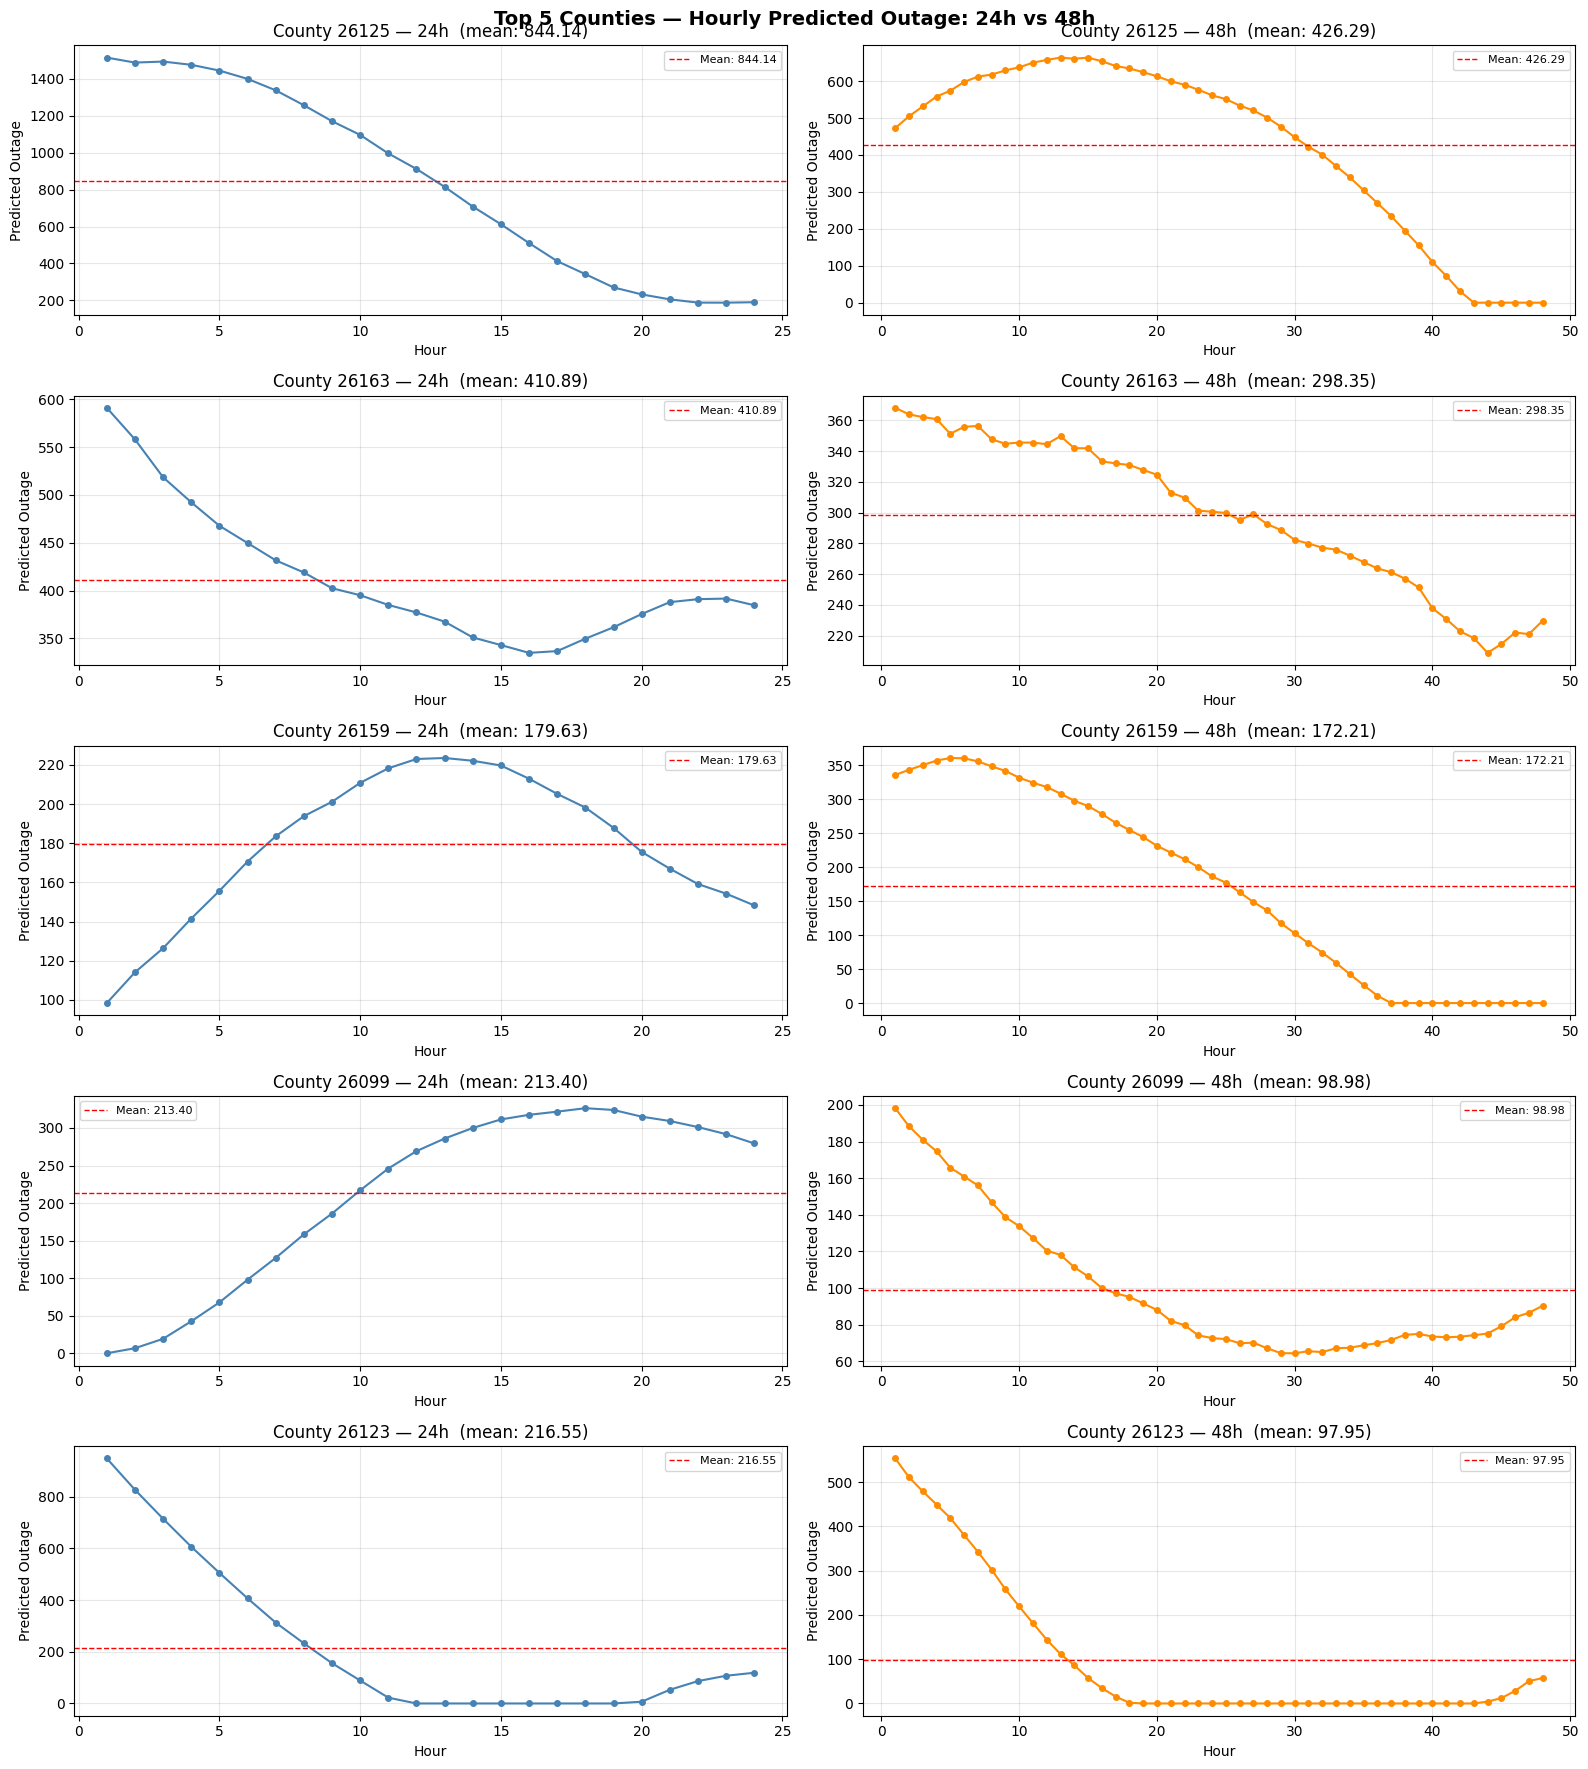

✓ Saved top5_counties_24h_vs_48h.png


In [23]:
# Top 5 counties by mean predicted outage (ranked by 48h) — 24h vs 48h comparison

mean_pred_48h = test_pred_48h.groupby('location')['pred'].mean()
top5_locs = mean_pred_48h.nlargest(5).index.tolist()

print("Top 5 Counties by Mean Predicted Outage (48h):")
print(mean_pred_48h.nlargest(5))

fig, axes = plt.subplots(5, 2, figsize=(16, 18))
fig.suptitle("Top 5 Counties — Hourly Predicted Outage: 24h vs 48h", fontsize=14, fontweight='bold')

for i, loc in enumerate(top5_locs):
    # 24h
    loc_24 = test_pred_24h[test_pred_24h['location'].astype(str) == str(loc)].copy()
    loc_24 = loc_24.sort_values('timestamp').reset_index(drop=True)
    preds_24 = loc_24['pred'].values

    ax24 = axes[i][0]
    ax24.plot(range(1, len(preds_24)+1), preds_24, marker='o', markersize=4, color='steelblue')
    ax24.set_title(f"County {loc} — 24h  (mean: {preds_24.mean():.2f})")
    ax24.set_xlabel("Hour")
    ax24.set_ylabel("Predicted Outage")
    ax24.axhline(y=preds_24.mean(), color='red', linestyle='--', linewidth=1,
                 label=f'Mean: {preds_24.mean():.2f}')
    ax24.legend(fontsize=8)
    ax24.grid(True, alpha=0.3)

    # 48h
    loc_48 = test_pred_48h[test_pred_48h['location'].astype(str) == str(loc)].copy()
    loc_48 = loc_48.sort_values('timestamp').reset_index(drop=True)
    preds_48 = loc_48['pred'].values

    ax48 = axes[i][1]
    ax48.plot(range(1, len(preds_48)+1), preds_48, marker='o', markersize=4, color='darkorange')
    ax48.set_title(f"County {loc} — 48h  (mean: {preds_48.mean():.2f})")
    ax48.set_xlabel("Hour")
    ax48.set_ylabel("Predicted Outage")
    ax48.axhline(y=preds_48.mean(), color='red', linestyle='--', linewidth=1,
                 label=f'Mean: {preds_48.mean():.2f}')
    ax48.legend(fontsize=8)
    ax48.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "top5_counties_24h_vs_48h.png"), dpi=120)
plt.show()
print("✓ Saved top5_counties_24h_vs_48h.png")
